# **Problem Statement Selection**



# Brain Tumor Detection and Classification Using ANN

## Project Title
**Brain Tumor Detection and Classification Using Artificial Neural Network (ANN)**


## Problem Statement
Brain tumors are difficult to detect manually from MRI images and require expert analysis.
The objective of this project is to build an Artificial Neural Network (ANN) model that can
automatically analyze brain MRI images and classify them into different tumor categories.


## Business Objective
- To develop an AI-based system for automatic brain tumor detection.
- To assist doctors and radiologists in faster diagnosis.
- To reduce manual analysis effort and improve decision-making.
- To support early detection of brain tumor types.


## Expected Output
The trained ANN model takes a brain MRI image as input and predicts the tumor category.

**Input:** Brain MRI Image

**Output:** Predicted Tumor Class

Example:
- Glioma Tumor
- Meningioma Tumor
- Pituitary Tumor
- No Tumor


## Target Variable
The target variable is the **Brain Tumor Class** that the model predicts.

Classes:
- 0 → Glioma
- 1 → Meningioma
- 2 → Pituitary
- 3 → No Tumor


## Input Features
The input features are numerical representations extracted from MRI images.

Features include:
- MRI image pixel values
- HOG (Histogram of Oriented Gradients) features
- Image intensity values
- Texture and shape information

In [ ]:

import os
import cv2
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import hog

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf

import joblib

# Dataset Collection

In [ ]:
import zipfile

zip_path = "/content/disease.zip"   # Replace with your ZIP file name
extract_path = "dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
train_path = "/content/dataset/Training"
test_path = "/content/dataset/Testing"

In [ ]:
import os

print(os.listdir("dataset"))

['Training', 'Testing']


# Dataset Import

Verify the Classes

In [ ]:
classes = os.listdir(train_path)

print("Classes:", classes)
print("Number of Classes:", len(classes))

Classes: ['glioma', 'pituitary', 'notumor', 'meningioma']
Number of Classes: 4


 Display the Number of Images in Each Class

In [ ]:
# Count images in each class

total_images = 0

for folder in classes:
    folder_path = os.path.join(train_path, folder)
    count = len(os.listdir(folder_path))

    print(f"{folder} : {count}")

    total_images += count

print("\nTotal Training Images :", total_images)

glioma : 1400
pituitary : 1400
notumor : 1400
meningioma : 1400

Total Training Images : 5600


Display One Sample Image from Each Class

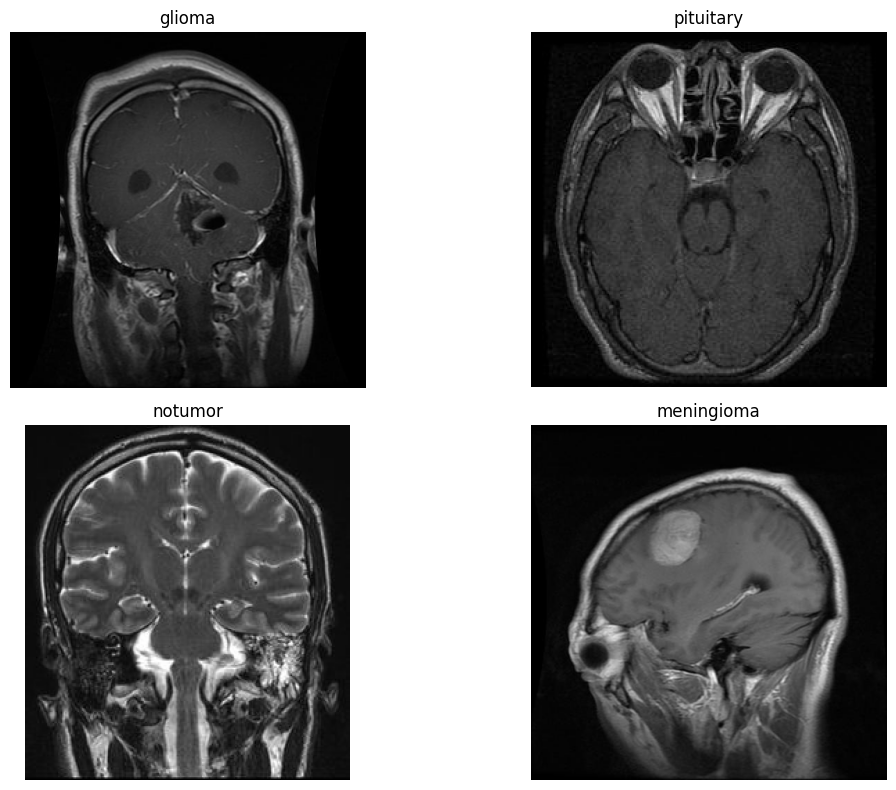

In [ ]:
import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(12, 8))

for i, folder in enumerate(classes):

    image_name = os.listdir(os.path.join(train_path, folder))[0]

    image_path = os.path.join(train_path, folder, image_name)

    image = cv2.imread(image_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 2, i + 1)
    plt.imshow(image)
    plt.title(folder)
    plt.axis("off")

plt.tight_layout()
plt.show()

Display Image Shape

In [ ]:
image = cv2.imread(image_path)
print("Image Shape:", image.shape)

Image Shape: (512, 512, 3)


# Exploratory Data Analysis

Count Plot

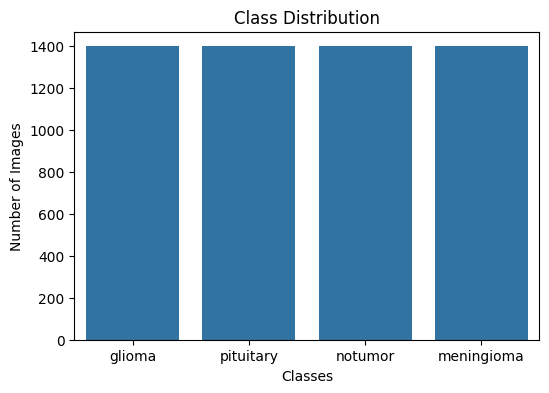

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

class_counts = [len(os.listdir(os.path.join(train_path, cls))) for cls in classes]

plt.figure(figsize=(6, 4))
sns.barplot(x=classes, y=class_counts)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

Pie Chart

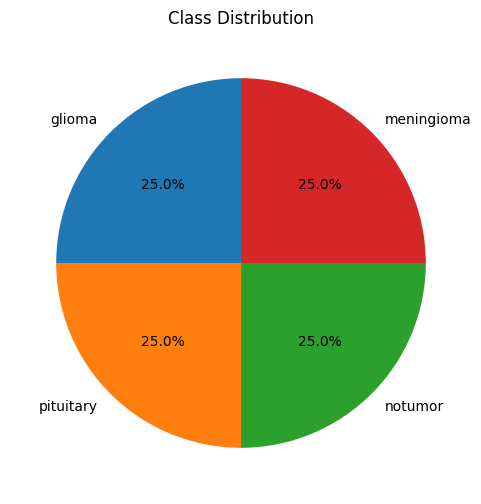

In [ ]:
plt.figure(figsize=(6, 6))
plt.pie(class_counts, labels=classes, autopct='%1.1f%%', startangle=90)
plt.title("Class Distribution")
plt.show()

#Image Preprocessing

Resize Images + HOG Feature Extraction

In [ ]:
import os
import cv2
import numpy as np
from skimage.feature import hog

IMG_SIZE = 128

X = []
y = []

for label in classes:

    folder_path = os.path.join(train_path, label)

    for image_name in os.listdir(folder_path):

        image_path = os.path.join(folder_path, image_name)

        image = cv2.imread(image_path)

        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        gray = gray / 255.0

        features = hog(
            gray,
            orientations=9,
            pixels_per_cell=(8,8),
            cells_per_block=(2,2),
            block_norm='L2-Hys'
        )

        X.append(features)
        y.append(label)

#Convert to NumPy Arrays

In [ ]:
X = np.array(X)
y = np.array(y)

print("Feature Shape :", X.shape)
print("Label Shape :", y.shape)

Feature Shape : (5600, 8100)
Label Shape : (5600,)


#Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

print(le.classes_)

['glioma' 'meningioma' 'notumor' 'pituitary']


#Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
X = np.array(X)

print(type(X))
print(X.shape)

<class 'numpy.ndarray'>
(5600, 8100)


#Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4480, 8100)
(1120, 8100)
(4480,)
(1120,)


#ANN Model Building.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

model.add(Dense(256, activation='relu', input_shape=(8100,)))
model.add(Dropout(0.3))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))

model.add(Dense(4, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#Model Summary

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     2,073,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,115,268 (8.07 MB)

 Trainable params: 2,115,268 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

#Train the Model

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.6971 - loss: 0.7646 - val_accuracy: 0.7973 - val_loss: 0.5104
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8328 - loss: 0.4549 - val_accuracy: 0.8670 - val_loss: 0.3467
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8621 - loss: 0.3720 - val_accuracy: 0.8795 - val_loss: 0.3048
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8864 - loss: 0.3108 - val_accuracy: 0.8357 - val_loss: 0.3937
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8911 - loss: 0.2964 - val_accuracy: 0.8848 - val_loss: 0.2955
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8944 - loss: 0.2776 - val_accuracy: 0.8598 - val_loss: 0.3843
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8940 - loss: 0.2802 - val_accuracy: 0.8616 - val_loss: 0.3537
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9094 - loss: 0.2478 - val_accu

#Evaluate the Model

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9196 - loss: 0.3050
Test Loss: 0.30496785044670105
Test Accuracy: 0.9196428656578064


#Predictions

In [ ]:
y_pred = model.predict(X_test)
y_pred = y_pred.argmax(axis=1)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


#Confusion Matrix

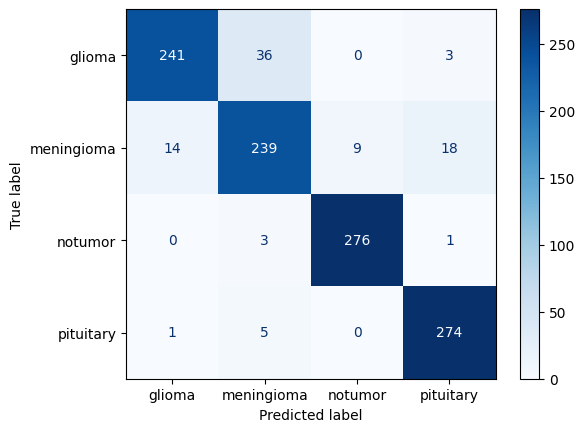

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues")
plt.show()

#Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

      glioma       0.94      0.86      0.90       280
  meningioma       0.84      0.85      0.85       280
     notumor       0.97      0.99      0.98       280
   pituitary       0.93      0.98      0.95       280

    accuracy                           0.92      1120
   macro avg       0.92      0.92      0.92      1120
weighted avg       0.92      0.92      0.92      1120



#Save the Model

In [ ]:
model.save("brain_tumor_ann.keras")

#Hyperparameter Tuning with Optuna

Install Optuna

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 24.7 MB/s eta 0:00:00


#Import Libraries

In [ ]:
import optuna
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

#Objective Function

In [ ]:
def objective(trial):

    n1 = trial.suggest_int("n1", 64, 512)
    n2 = trial.suggest_int("n2", 32, 256)
    dropout = trial.suggest_float("dropout", 0.2, 0.5)
    lr = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)

    model = Sequential()

    model.add(Dense(n1, activation="relu", input_shape=(X_train.shape[1],)))
    model.add(Dropout(dropout))

    model.add(Dense(n2, activation="relu"))
    model.add(Dropout(dropout))

    model.add(Dense(4, activation="softmax"))

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=10,
        batch_size=32,
        verbose=0
    )

    return max(history.history["val_accuracy"])

#Run Optuna

In [ ]:
study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=20)

[I 2026-08-01 17:22:22,890] A new study created in memory with name: no-name-4eaea4e4-630c-4033-8d47-1074fa00e3e1
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2026-08-01 17:22:49,844] Trial 0 finished with value: 0.8999999761581421 and parameters: {'n1': 224, 'n2': 43, 'dropout': 0.3968164567527151, 'learning_rate': 0.00015667374762454747}. Best is trial 0 with value: 0.8999999761581421.
[I 2026-08-01 17:23:15,943] Trial 1 finished with value: 0.9151785969734192 and parameters: {'n1': 196, 'n2': 68, 'dropout': 0.27485561888210813, 'learning_rate': 0.0002480792913972645}. Best is trial 1 with value: 0.9151785969734192.
[I 2026-08-01 17:23:48,475] Trial 2 finished with value: 0.9303571581840515 and para

#Best Parameters

In [ ]:
print(study.best_params)

{'n1': 262, 'n2': 56, 'dropout': 0.24891506447323286, 'learning_rate': 0.0006934884257758383}


#Best Validation Accuracy

In [ ]:
print(study.best_value)

0.9312499761581421


#Train Final Model

In [ ]:
best = study.best_params

model = Sequential()

model.add(Dense(best["n1"], activation="relu", input_shape=(X_train.shape[1],)))
model.add(Dropout(best["dropout"]))

model.add(Dense(best["n2"], activation="relu"))
model.add(Dropout(best["dropout"]))

model.add(Dense(4, activation="softmax"))

model.compile(
    optimizer=Adam(learning_rate=best["learning_rate"]),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.7210 - loss: 0.7124 - val_accuracy: 0.8446 - val_loss: 0.4273
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8449 - loss: 0.4248 - val_accuracy: 0.8679 - val_loss: 0.3469
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8846 - loss: 0.3277 - val_accuracy: 0.8813 - val_loss: 0.2953
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8980 - loss: 0.2805 - val_accuracy: 0.8830 - val_loss: 0.3187
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9060 - loss: 0.2543 - val_accuracy: 0.8839 - val_loss: 0.3098
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9210 - loss: 0.2077 - val_accuracy: 0.9116 - val_loss: 0.2257
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9404 - loss: 0.1722 - val_accuracy: 0.9205 - val_loss: 0.2211
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9460 - loss: 0.1557 - val_accu

#Evaluate Final Model

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Final Accuracy:", accuracy)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9196 - loss: 0.2699
Final Accuracy: 0.9196428656578064


In [ ]:
model.save("brain_tumor_ann_best.keras")

#Save Final Model

In [ ]:
import joblib

joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']